# Gauge & Resolution Comparison

Compare energy-density profiles $\rho(r)$ and key diagnostics across runs
with different gauge conditions and grid resolutions.

Data lives in `$VSC_DATA/gauge_testing/` (separate from production runs).

In [1]:
import os, re, glob
import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict

import sys
NOTEBOOK_DIR = os.path.abspath("")
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, "..", ".."))
sys.path.insert(0, PROJECT_ROOT)

from core.grid import Grid
from core.spacing import CubicSpacing
from core.statevector import StateVector
from matter.scalarmatter_MG import ScalarMatter
from bssn.oscillondiagnostic import get_oscillon_diagnostic
from backgrounds.sphericalbackground import FlatSphericalBackground

## 1. Discover available runs

In [2]:
VSC_DATA = os.environ.get("VSC_DATA", os.path.join(NOTEBOOK_DIR, "..", "DATA"))
GAUGE_DIR = os.path.join(VSC_DATA, "gauge_testing")

def parse_run_tag(tag):
    """Extract parameters from a gauge_testing run folder name."""
    info = {}
    m = re.search(r'gauge_([\w]+)_eta', tag)
    if m: info['gauge_type'] = m.group(1)
    for key in ['eta', 'lgb', 'mu', 'amp', 'R', 'maxdr', 'dr']:
        m = re.search(rf'_{key}([\-\d.e]+)', tag)
        if m:
            try: info[key] = float(m.group(1))
            except ValueError: info[key] = m.group(1)
    # a and b need underscore boundaries to avoid matching eta/lgb
    m = re.search(r'_a([\-\d.e]+)_b', tag)
    if m:
        try: info['a'] = float(m.group(1))
        except ValueError: info['a'] = m.group(1)
    m = re.search(r'_b([\-\d.e]+)_amp', tag)
    if m:
        try: info['b'] = float(m.group(1))
        except ValueError: info['b'] = m.group(1)
    return info

if os.path.isdir(GAUGE_DIR):
    all_tags = sorted([d for d in os.listdir(GAUGE_DIR)
                       if os.path.isdir(os.path.join(GAUGE_DIR, d))])
else:
    all_tags = []

print(f"Data directory: {GAUGE_DIR}")
print(f"Found {len(all_tags)} run(s):\n")
for i, tag in enumerate(all_tags):
    info = parse_run_tag(tag)
    has_diag = os.path.exists(os.path.join(GAUGE_DIR, tag, "diagnostics.npz"))
    status = "[diag]" if has_diag else "[no diag]"
    print(f"  {i:2d}  {status}  {tag}")
    print(f"       {info}")

Data directory: /data/leuven/384/vsc38419/gauge_testing
Found 6 run(s):

   0  [diag]  gauge_baumgarte_eta1.0_lgb0.0_mu0.08_a0.2_b0.4_amp-0.02_R3.0_dr0.08333333_maxdr2.0
       {'gauge_type': 'baumgarte', 'eta': 1.0, 'lgb': 0.0, 'mu': 0.08, 'amp': -0.02, 'R': 3.0, 'maxdr': 2.0, 'dr': 0.08333333, 'a': 0.2, 'b': 0.4}
   1  [diag]  gauge_baumgarte_eta1.0_lgb0.0_mu0.08_a0.2_b0.4_amp-0.02_R3.0_dr0.125_maxdr2.0
       {'gauge_type': 'baumgarte', 'eta': 1.0, 'lgb': 0.0, 'mu': 0.08, 'amp': -0.02, 'R': 3.0, 'maxdr': 2.0, 'dr': 0.125, 'a': 0.2, 'b': 0.4}
   2  [diag]  gauge_bona_masso_eta1.0_lgb0.0_mu0.08_a0.2_b0.4_amp-0.02_R3.0_dr0.08333333_maxdr2.0
       {'gauge_type': 'bona_masso', 'eta': 1.0, 'lgb': 0.0, 'mu': 0.08, 'amp': -0.02, 'R': 3.0, 'maxdr': 2.0, 'dr': 0.08333333, 'a': 0.2, 'b': 0.4}
   3  [diag]  gauge_bona_masso_eta1.0_lgb0.0_mu0.08_a0.2_b0.4_amp-0.02_R3.0_dr0.125_maxdr2.0
       {'gauge_type': 'bona_masso', 'eta': 1.0, 'lgb': 0.0, 'mu': 0.08, 'amp': -0.02, 'R': 3.0, 'maxdr': 2.0, 

## 2. Select runs to compare

In [3]:
# ── Filter: pick runs by index or by parameter ──
# Option A: select by index from the list above
# selected_indices = [0, 1, 2]
# selected_tags = [all_tags[i] for i in selected_indices]

# Option B: select all runs (default)
selected_tags = all_tags

# Option C: filter by gauge type
# selected_tags = [t for t in all_tags if 'baumgarte' in t]

# Option D: filter by resolution
# selected_tags = [t for t in all_tags if 'dr0.03125' in t or 'dr0.0625' in t]

print(f"Selected {len(selected_tags)} run(s) for comparison")

Selected 6 run(s) for comparison


## 3. Load diagnostics

In [4]:
TABLE_I = {
    0.04: dict(phi=-6.03334e-2, dphi=2.20256e-2, H=1.55744e-2),
    0.05: dict(phi=-7.36454e-2, dphi=2.72499e-2, H=1.92686e-2),
    0.06: dict(phi=-8.64102e-2, dphi=3.23761e-2, H=2.28934e-2),
    0.07: dict(phi=-9.86792e-2, dphi=3.74094e-2, H=2.64525e-2),
    0.08: dict(phi=-1.10495e-1, dphi=4.23540e-2, H=2.99488e-2),
    0.09: dict(phi=-1.21893e-1, dphi=4.72136e-2, H=3.33851e-2),
    0.10: dict(phi=-1.32906e-1, dphi=5.19917e-2, H=3.67637e-2),
}

RECOMPUTE_DIAGNOSTICS = False  # set True to recompute from solution.npy

runs = OrderedDict()  # tag -> {"info": ..., "osc": ..., "meta": ...}

for tag in selected_tags:
    run_dir = os.path.join(GAUGE_DIR, tag)
    info = parse_run_tag(tag)

    diag_path = os.path.join(run_dir, "diagnostics.npz")
    sol_path  = os.path.join(run_dir, "solution.npy")

    if os.path.exists(diag_path) and not RECOMPUTE_DIAGNOSTICS:
        osc = dict(np.load(diag_path, allow_pickle=True))
    elif os.path.exists(sol_path):
        print(f"  Computing diagnostics for {tag} ...")
        solution = np.load(sol_path)
        t_arr = np.load(os.path.join(run_dir, "t.npy"))
        r_arr = np.load(os.path.join(run_dir, "r.npy"))

        mu_val  = info.get('mu', 0.08)
        lgb_val = info.get('lgb', 0.0)
        a_val   = info.get('a', 0.2)
        b_val   = info.get('b', 0.4)

        meta_path = os.path.join(run_dir, "metadata.npz")
        if os.path.exists(meta_path):
            meta = dict(np.load(meta_path, allow_pickle=True))
            coupling = str(meta.get('coupling', 'quadratic'))
            chi0_val = float(meta.get('chi0', 0.15))
            min_dr   = float(meta.get('min_dr', 1/16))
            max_dr   = float(meta.get('max_dr', 2))
            r_max    = float(meta.get('r_max', 150))
        else:
            coupling = 'quadratic'; chi0_val = 0.15
            min_dr = info.get('dr', 1/16); max_dr = info.get('maxdr', 2); r_max = 150

        matter  = ScalarMatter(1, mu_val)
        sv      = StateVector(matter)
        spacing = CubicSpacing(**CubicSpacing.get_parameters(r_max, min_dr, max_dr))
        grid    = Grid(spacing, sv)
        bg      = FlatSphericalBackground(grid.r)
        params  = (lgb_val, a_val, b_val, chi0_val, coupling)

        osc = get_oscillon_diagnostic(
            solution, t_arr, grid, bg,
            ScalarMatter(1, mu_val), params,
            surface_threshold=0.05, r_max_diag=100.0,
        )
        np.savez(diag_path, **osc)
        print(f"    saved diagnostics -> {diag_path}")
    else:
        print(f"  SKIP {tag}: no solution.npy found")
        continue

    meta = {}
    meta_path = os.path.join(run_dir, "metadata.npz")
    if os.path.exists(meta_path):
        meta = dict(np.load(meta_path, allow_pickle=True))

    runs[tag] = {"info": info, "osc": osc, "meta": meta}

print(f"\nLoaded {len(runs)} run(s)")


Loaded 6 run(s)


## 4. Build short labels for legends

In [5]:
def make_label(info):
    """Short human-readable label highlighting gauge & resolution."""
    gauge = info.get('gauge_type', '?')
    dr    = info.get('dr', '?')
    eta   = info.get('eta', 1.0)
    a     = info.get('a', 0.2)
    b     = info.get('b', 0.4)
    parts = [gauge, f"dr={dr}"]
    if eta != 1.0:
        parts.append(f"η={eta}")
    if a != 0.2 or b != 0.4:
        parts.append(f"a={a},b={b}")
    return ", ".join(parts)

labels = {tag: make_label(d["info"]) for tag, d in runs.items()}
for tag, lbl in labels.items():
    print(f"  {lbl:40s}  <- {tag}")

  baumgarte, dr=0.08333333                  <- gauge_baumgarte_eta1.0_lgb0.0_mu0.08_a0.2_b0.4_amp-0.02_R3.0_dr0.08333333_maxdr2.0
  baumgarte, dr=0.125                       <- gauge_baumgarte_eta1.0_lgb0.0_mu0.08_a0.2_b0.4_amp-0.02_R3.0_dr0.125_maxdr2.0
  bona_masso, dr=0.08333333                 <- gauge_bona_masso_eta1.0_lgb0.0_mu0.08_a0.2_b0.4_amp-0.02_R3.0_dr0.08333333_maxdr2.0
  bona_masso, dr=0.125                      <- gauge_bona_masso_eta1.0_lgb0.0_mu0.08_a0.2_b0.4_amp-0.02_R3.0_dr0.125_maxdr2.0
  modified_harmonic, dr=0.08333333          <- gauge_modified_harmonic_eta1.0_lgb0.0_mu0.08_a0.2_b0.4_amp-0.02_R3.0_dr0.08333333_maxdr2.0
  modified_harmonic, dr=0.125               <- gauge_modified_harmonic_eta1.0_lgb0.0_mu0.08_a0.2_b0.4_amp-0.02_R3.0_dr0.125_maxdr2.0


## 5. Energy-density profiles $\rho(r)$ at selected $\ln(a)$

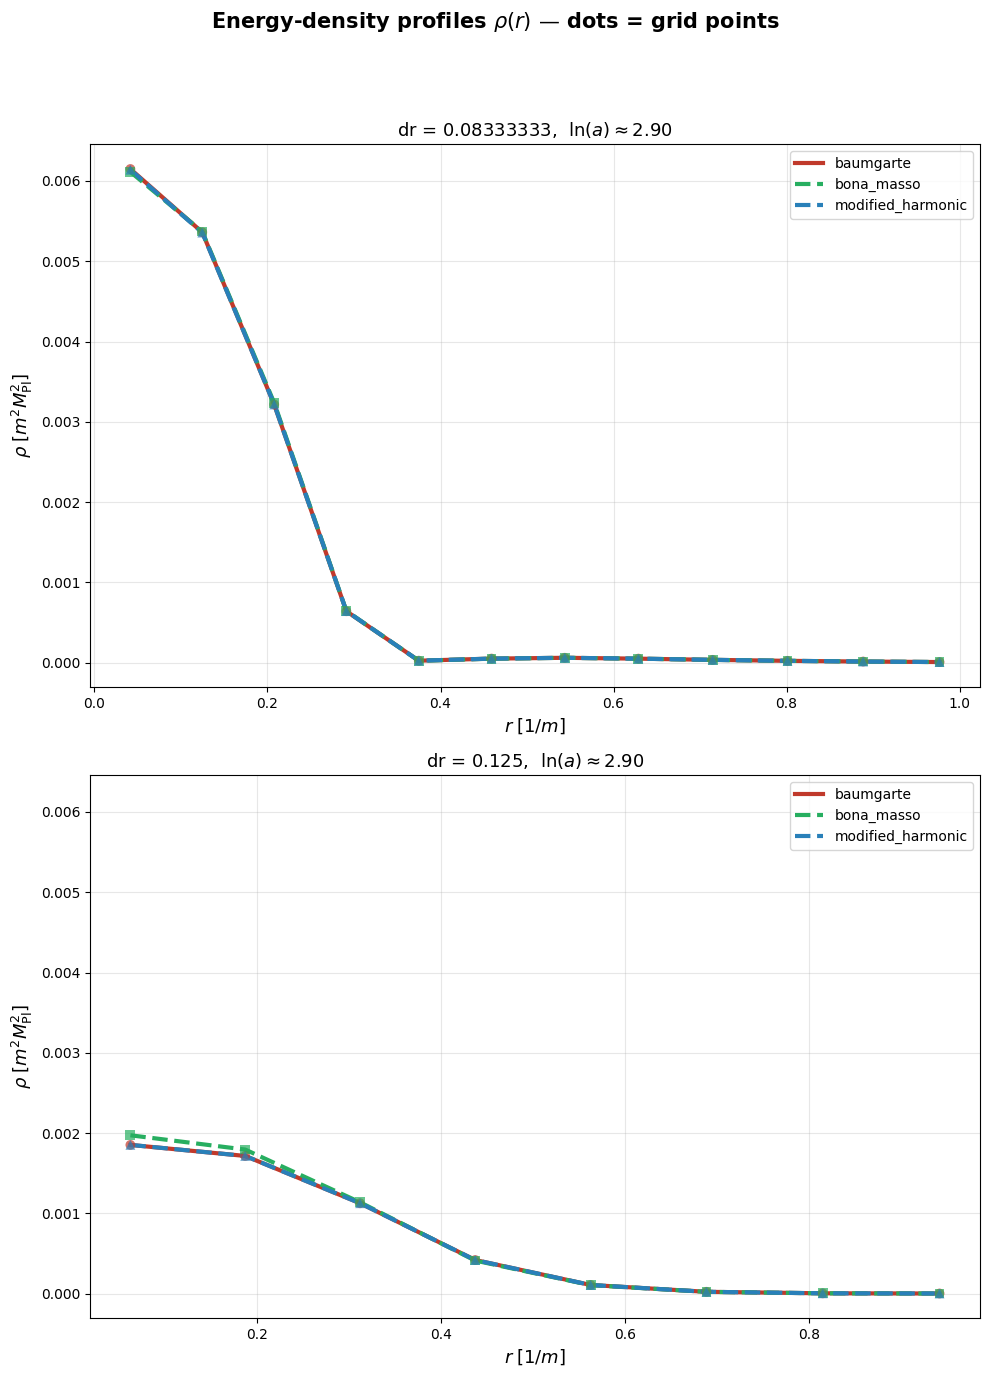

In [40]:
snapshot_lna_values = [2.9]  # choose ln(a) values for snapshots
r_plot_max = 1                            # max radius to show
SHOW_GRIDPOINTS = True                         # show grid points as markers on lines
GRIDPOINT_SIZE  = 50                 # marker size for grid points

# ── Comparison mode ──
# "gauge"      : each row = one resolution, overlay different gauges
# "resolution" : each row = one gauge,      overlay different resolutions
COMPARE_MODE = "gauge"  # "gauge" or "resolution"
colors = ["red", "green", "blue", "#8e44ad", "#3498db", "#f1c40f", "#e74c3c", "#9b59b6", "#2ecc71", "#f39c12"]

markers_cycle = ["o", "s", "^", "D", "v", "P", "X", "*"]
gauge_colors = {"modified_harmonic": "#2980b9", "baumgarte": "#c0392b", "bona_masso": "#27ae60"}
res_colors  = {0.125: "#e67e22", 0.08333333: "#8e44ad"}

from collections import defaultdict
res_groups = defaultdict(list)
gauge_groups = defaultdict(list)
for tag, d in runs.items():
    dr_val = d["info"].get("dr", 0)
    gauge  = d["info"].get("gauge_type", "?")
    res_groups[dr_val].append(tag)
    gauge_groups[gauge].append(tag)

resolutions = sorted(res_groups.keys())
gauges      = sorted(gauge_groups.keys())
n_snaps = len(snapshot_lna_values)

if COMPARE_MODE == "gauge":
    row_keys  = resolutions
    row_label = lambda k: f"dr = {k}"
    get_tags  = lambda k: res_groups[k]
    get_color = lambda d: gauge_colors.get(d["info"].get("gauge_type","?"), "C0")
    get_ls    = lambda d: "-" if d["info"].get("gauge_type","") == "baumgarte" else "--"
    get_leg   = lambda d: d["info"].get("gauge_type", "?")
else:
    row_keys  = gauges
    row_label = lambda k: k
    get_tags  = lambda k: gauge_groups[k]
    get_color = lambda d: res_colors.get(d["info"].get("dr",0), "C0")
    get_ls    = lambda d: "-" if d["info"].get("dr",0) == min(resolutions) else "--"
    get_leg   = lambda d: f"dr = {d['info'].get('dr','?')}"

n_rows = len(row_keys)

fig, axes = plt.subplots(n_rows, n_snaps, figsize=(10 * n_snaps, 7 * n_rows),
                          squeeze=False, sharey=True)

for row, rk in enumerate(row_keys):
    tags_in_row = get_tags(rk)
    for col, target_lna in enumerate(snapshot_lna_values):
        ax = axes[row, col]
        for idx, tag in enumerate(sorted(tags_in_row)):
            d = runs[tag]
            osc = d["osc"]
            r   = osc["r"]
            ln_a = osc["ln_a"]
            rho  = osc["rho"]

            snap_idx = np.argmin(np.abs(ln_a - target_lna))
            r_mask = (r > 0) & (r <= r_plot_max)

            ax.plot(r[r_mask], rho[snap_idx, r_mask],
                    color=get_color(d), lw=3, ls=get_ls(d), label=get_leg(d))

            if SHOW_GRIDPOINTS:
                mk = markers_cycle[idx % len(markers_cycle)]
                ax.scatter(r[r_mask], rho[snap_idx, r_mask],
                           color=get_color(d), marker=mk, s=GRIDPOINT_SIZE,
                           zorder=10, edgecolors="none", alpha=0.7)

        actual_lna = osc["ln_a"][snap_idx]
        ax.set_title(rf"{row_label(rk)},  $\ln(a) \approx {actual_lna:.2f}$", fontsize=13)
        ax.set_xlabel(r"$r\;[1/m]$", fontsize=13)
        if col == 0:
            ax.set_ylabel(r"$\rho\;[m^2 M_{\rm Pl}^2]$", fontsize=13)
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)

fig.suptitle(r"Energy-density profiles $\rho(r)$ — dots = grid points",
             fontsize=15, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

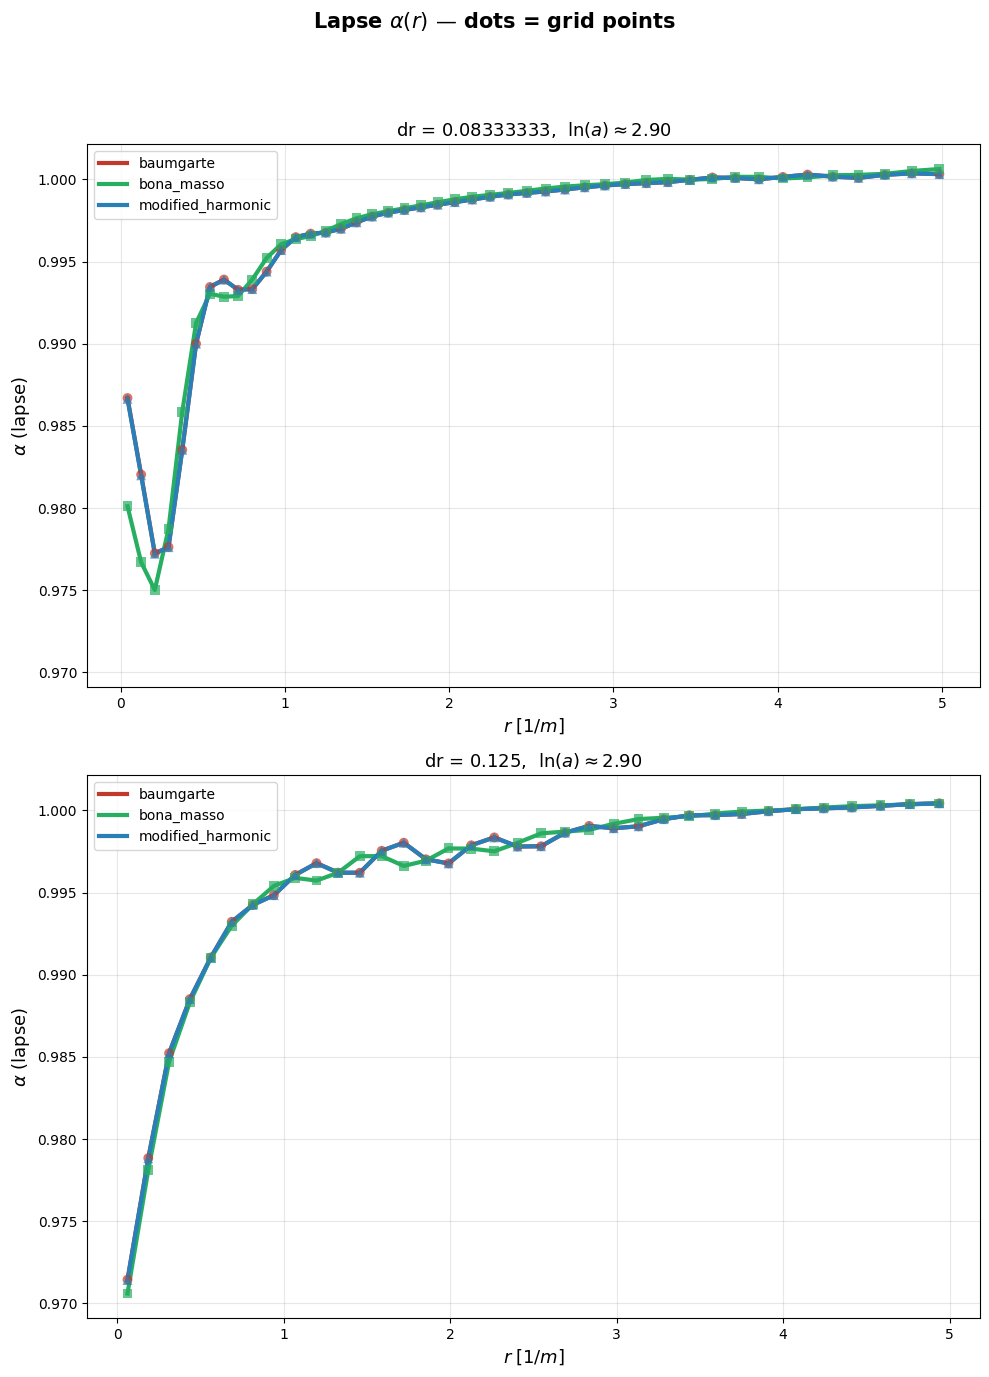

In [41]:
# ── Lapse profiles at the same snapshots ──
IDX_LAPSE = 11  # lapse index in the BSSN state vector
#IDX_LAPSE = 4  # extrinsic curvature index in the BSSN state vector
r_plot_max_lapse = 5

fig_l, axes_l = plt.subplots(n_rows, n_snaps, figsize=(10 * n_snaps, 7 * n_rows),
                              squeeze=False, sharey=True)

for row, rk in enumerate(row_keys):
    tags_in_row = get_tags(rk)
    for col, target_lna in enumerate(snapshot_lna_values):
        ax = axes_l[row, col]
        for idx, tag in enumerate(sorted(tags_in_row)):
            d = runs[tag]
            osc = d["osc"]
            r   = osc["r"]
            ln_a = osc["ln_a"]

            snap_idx = np.argmin(np.abs(ln_a - target_lna))
            r_mask = (r > 0) & (r <= r_plot_max_lapse)

            run_dir = os.path.join(GAUGE_DIR, tag)
            sol = np.load(os.path.join(run_dir, "solution.npy"))
            NUM_VARS = sol.shape[1] // len(r)
            state = sol[snap_idx].reshape(NUM_VARS, -1)
            lapse = state[IDX_LAPSE]

            ax.plot(r[r_mask], lapse[r_mask],
                    color=get_color(d), lw=3, label=get_leg(d))#, ls=get_ls(d))

            if SHOW_GRIDPOINTS:
                mk = markers_cycle[idx % len(markers_cycle)]
                ax.scatter(r[r_mask], lapse[r_mask],
                           color=get_color(d), marker=mk, s=GRIDPOINT_SIZE,
                           zorder=10, edgecolors="none", alpha=0.7)

        actual_lna = osc["ln_a"][snap_idx]
        ax.set_title(rf"{row_label(rk)},  $\ln(a) \approx {actual_lna:.2f}$", fontsize=13)
        ax.set_xlabel(r"$r\;[1/m]$", fontsize=13)
        if col == 0:
            ax.set_ylabel(r"$\alpha$ (lapse)", fontsize=13)
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)

fig_l.suptitle(r"Lapse $\alpha(r)$ — dots = grid points",
               fontsize=15, fontweight="bold")
fig_l.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

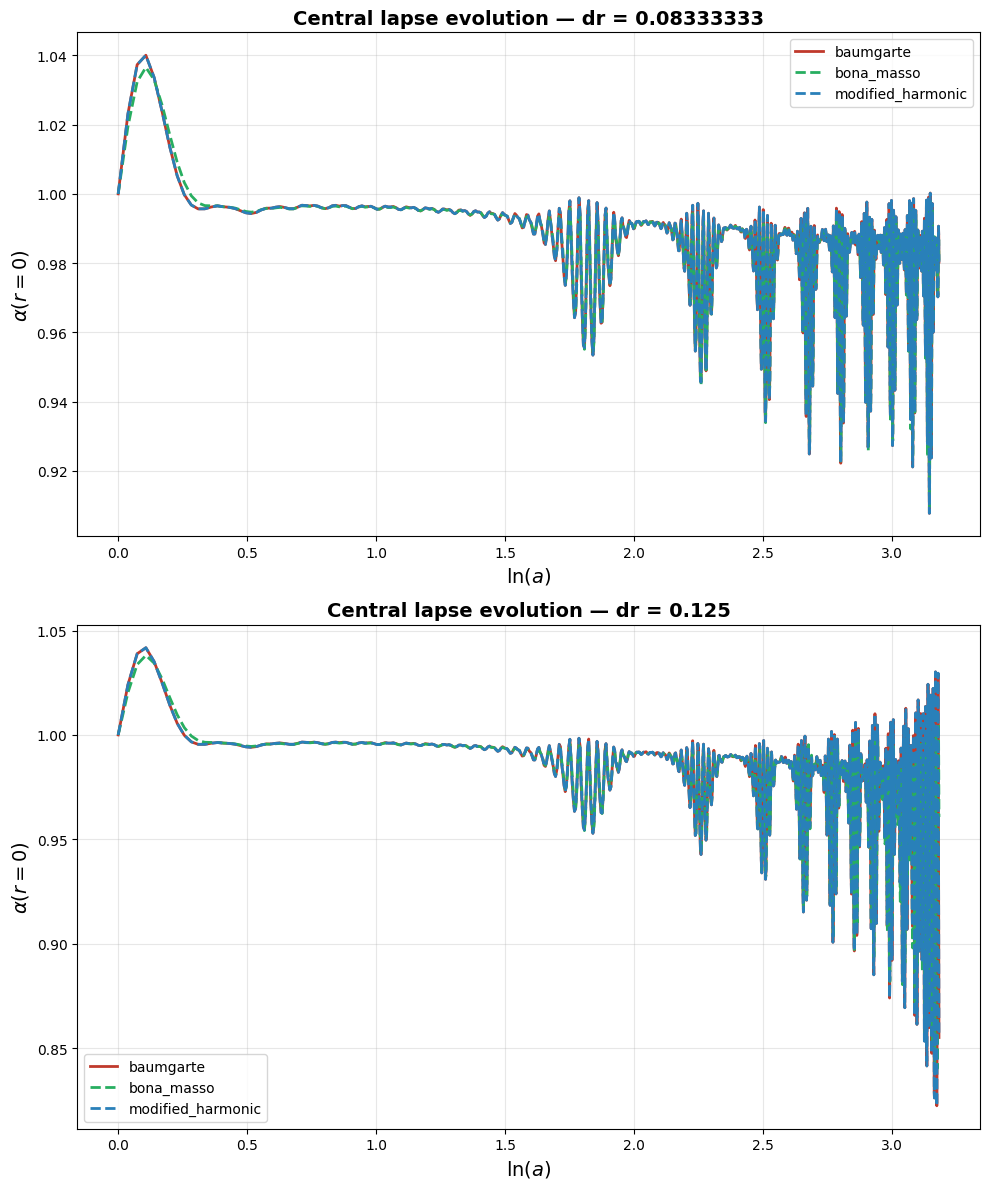

In [39]:
# ── Central lapse vs ln(a) ──
fig_lt, axes_lt = plt.subplots(n_rows, 1, figsize=(10, 6 * n_rows), squeeze=False)

for row, rk in enumerate(row_keys):
    ax = axes_lt[row, 0]
    tags_in_row = get_tags(rk)
    for idx, tag in enumerate(sorted(tags_in_row)):
        d = runs[tag]
        osc = d["osc"]
        r   = osc["r"]
        ln_a = osc["ln_a"]

        run_dir = os.path.join(GAUGE_DIR, tag)
        sol = np.load(os.path.join(run_dir, "solution.npy"))
        NUM_VARS = sol.shape[1] // len(r)
        idx_center = np.argmin(np.abs(r))
        lapse_central = sol[:, IDX_LAPSE * len(r) + idx_center]

        ax.plot(ln_a, lapse_central, color=get_color(d), lw=2, ls=get_ls(d), label=get_leg(d))

    ax.set_xlabel(r"$\ln(a)$", fontsize=14)
    ax.set_ylabel(r"$\alpha(r=0)$", fontsize=14)
    ax.set_title(f"Central lapse evolution — {row_label(rk)}", fontsize=14, fontweight="bold")

    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

fig_lt.tight_layout()
plt.show()

## 6. Density-contrast profiles $\delta(r)$ at selected $\ln(a)$

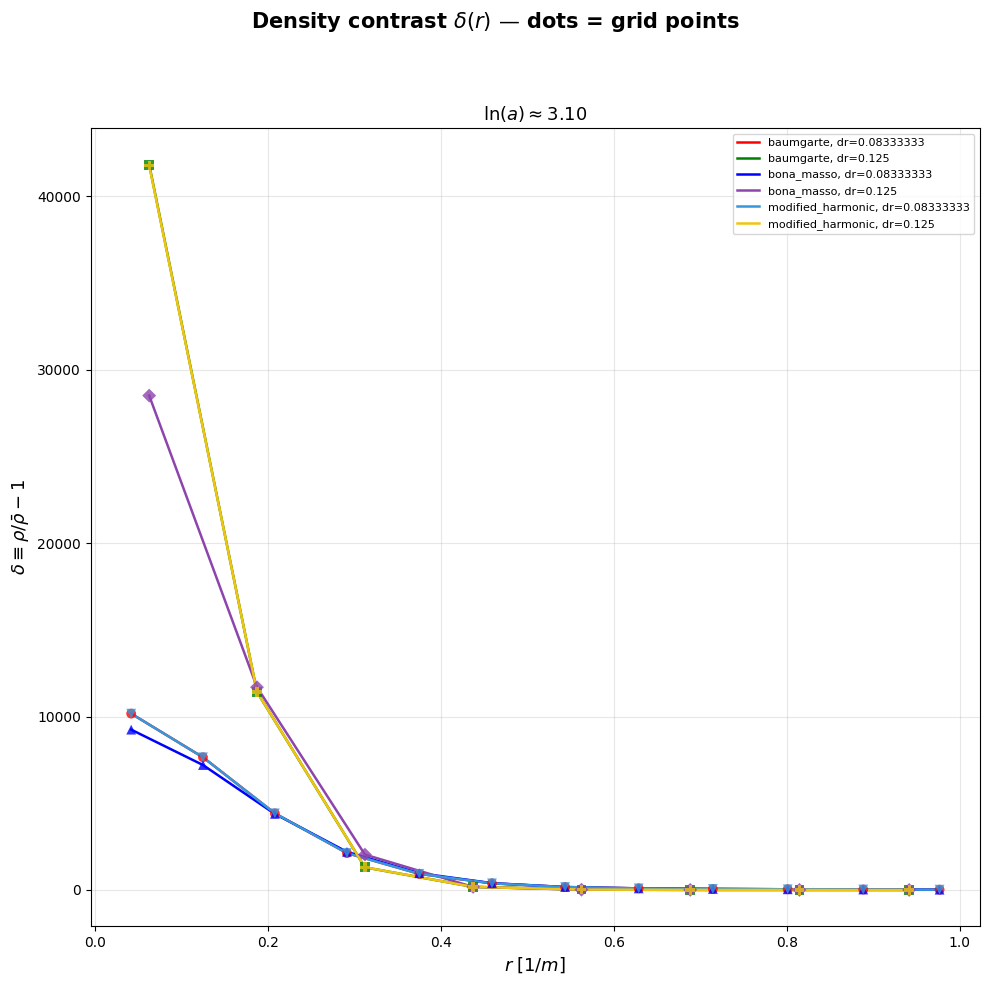

In [25]:
fig, axes = plt.subplots(1, n_snaps, figsize=(10 * n_snaps, 10), sharey=True)
if n_snaps == 1:
    axes = [axes]

for ax_i, target_lna in enumerate(snapshot_lna_values):
    ax = axes[ax_i]
    for idx, (tag, d) in enumerate(runs.items()):
        osc = d["osc"]
        r   = osc["r"]
        ln_a = osc["ln_a"]
        delta = osc["delta_rho"]

        snap_idx = np.argmin(np.abs(ln_a - target_lna))
        r_mask = (r > 0) & (r <= r_plot_max)

        ax.plot(r[r_mask], delta[snap_idx, r_mask],
                color=colors[idx], lw=1.8, label=labels[tag])

        if SHOW_GRIDPOINTS:
            mk = markers_cycle[idx % len(markers_cycle)]
            ax.scatter(r[r_mask], delta[snap_idx, r_mask],
                       color=colors[idx], marker=mk, s=GRIDPOINT_SIZE,
                       zorder=5, edgecolors="none", alpha=0.8)

    ax.set_xlabel(r"$r\;[1/m]$", fontsize=13)
    if ax_i == 0:
        ax.set_ylabel(r"$\delta \equiv \rho/\bar{\rho} - 1$", fontsize=13)
    actual_lna = osc["ln_a"][snap_idx]
    ax.set_title(rf"$\ln(a) \approx {actual_lna:.2f}$", fontsize=13)
    ax.grid(True, alpha=0.3)

axes[-1].legend(fontsize=8, loc="upper right")
fig.suptitle(r"Density contrast $\delta(r)$ — dots = grid points",
             fontsize=15, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

## 9. Oscillon mass and radius

<>:11: SyntaxWarning: invalid escape sequence '\l'
<>:11: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_2343262/1249266047.py:11: SyntaxWarning: invalid escape sequence '\l'
  """


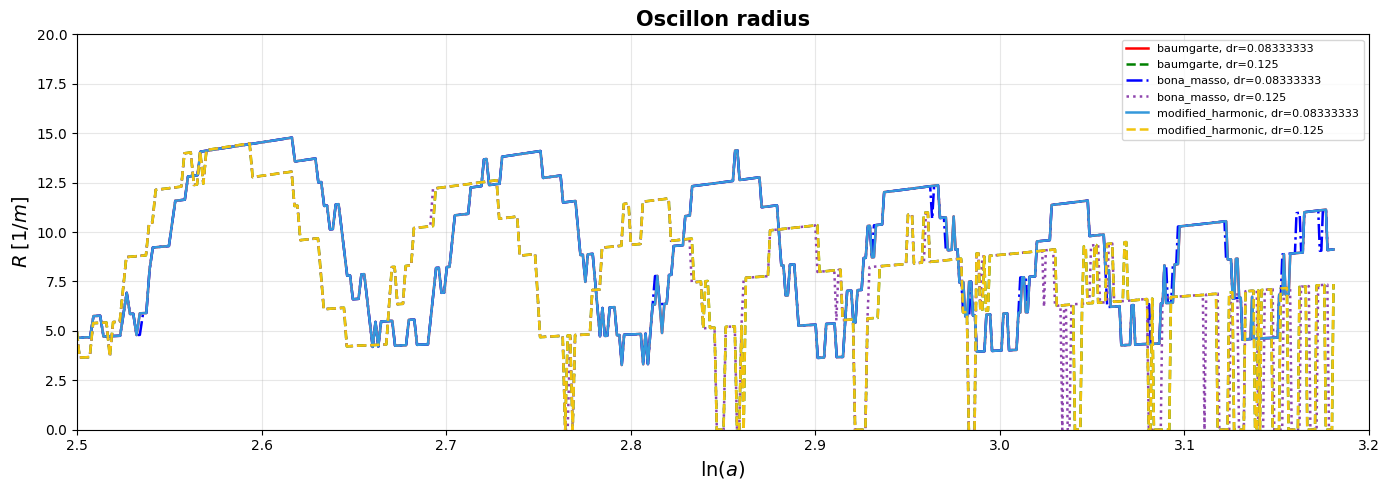

In [24]:
fig, (ax_r) = plt.subplots(1, 1, figsize=(14, 5))

line_style = ["-", "--", "-.", ":", "-", "--", "-.", ":"]

for idx, (tag, d) in enumerate(runs.items()):
    osc = d["osc"]
    ln_a = osc["ln_a"]
    #ax_m.plot(ln_a, osc["M"], color=colors[idx], lw=1.8, label=labels[tag])
    ax_r.plot(ln_a, osc["R"], color=colors[idx], lw=1.8, label=labels[tag], linestyle=line_style[idx])

"""
ax_m.set_xlabel(r"$\ln(a)$", fontsize=14)
ax_m.set_ylabel(r"$M\;[M_{\rm Pl}^2/m]$", fontsize=14)
ax_m.set_title("Oscillon mass", fontsize=15, fontweight="bold")
ax_m.legend(fontsize=8)
ax_m.grid(True, alpha=0.3)
"""
ax_r.set_xlabel(r"$\ln(a)$", fontsize=14)
ax_r.set_ylabel(r"$R\;[1/m]$", fontsize=14)
ax_r.set_title("Oscillon radius", fontsize=15, fontweight="bold")
ax_r.legend(fontsize=8)
ax_r.grid(True, alpha=0.3)

ax_r.set_xlim(2.5, 3.2)
ax_r.set_ylim(0, 20)

fig.tight_layout()
plt.show()

## 10. Convergence test: resolution comparison at fixed $\ln(a)$

In [ ]:
# Compare runs that differ ONLY in resolution (same gauge, same physics)
# Group runs by (gauge_type, lgb, mu, amp) — varying dr
from collections import defaultdict

convergence_lna = 2.5  # pick a ln(a) for the convergence snapshot

groups = defaultdict(list)
for tag, d in runs.items():
    info = d["info"]
    key = (info.get('gauge_type','?'), info.get('lgb',0), info.get('mu',0.08), info.get('amp',-0.02))
    groups[key].append(tag)

for group_key, tags_in_group in groups.items():
    if len(tags_in_group) < 2:
        continue

    tags_sorted = sorted(tags_in_group, key=lambda t: runs[t]["info"].get("dr", 999))

    fig, (ax_rho, ax_diff) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"Convergence: {group_key[0]}, λ_GB={group_key[1]}, μ={group_key[2]}",
                 fontsize=14, fontweight="bold")

    ref_tag = tags_sorted[0]  # finest resolution = reference
    ref_osc = runs[ref_tag]["osc"]
    ref_snap = np.argmin(np.abs(ref_osc["ln_a"] - convergence_lna))
    ref_r    = ref_osc["r"]
    ref_rho  = ref_osc["rho"][ref_snap]

    for j, tag in enumerate(tags_sorted):
        osc = runs[tag]["osc"]
        snap = np.argmin(np.abs(osc["ln_a"] - convergence_lna))
        r_arr = osc["r"]
        rho_snap = osc["rho"][snap]
        r_mask = (r_arr > 0) & (r_arr <= r_plot_max)

        dr_val = runs[tag]["info"].get("dr", "?")
        ax_rho.plot(r_arr[r_mask], rho_snap[r_mask], lw=1.5,
                    color=colors[j], label=f"dr={dr_val}")

        if SHOW_GRIDPOINTS:
            mk = markers_cycle[j % len(markers_cycle)]
            ax_rho.scatter(r_arr[r_mask], rho_snap[r_mask],
                           color=colors[j], marker=mk, s=GRIDPOINT_SIZE,
                           zorder=5, edgecolors="none", alpha=0.8)

        if tag != ref_tag:
            rho_interp = np.interp(ref_r, r_arr, rho_snap)
            diff = np.abs(rho_interp - ref_rho) / np.maximum(np.abs(ref_rho), 1e-30)
            ref_mask = (ref_r > 0) & (ref_r <= r_plot_max)
            ax_diff.semilogy(ref_r[ref_mask], diff[ref_mask], lw=1.5,
                             color=colors[j], label=f"dr={dr_val} vs ref")

    ax_rho.set_xlabel(r"$r\;[1/m]$"); ax_rho.set_ylabel(r"$\rho$")
    ax_rho.set_title(rf"$\ln(a) \approx {convergence_lna}$")
    ax_rho.legend(fontsize=9); ax_rho.grid(True, alpha=0.3)

    ax_diff.set_xlabel(r"$r\;[1/m]$"); ax_diff.set_ylabel(r"Relative difference")
    ax_diff.set_title("Relative difference vs finest resolution")
    ax_diff.legend(fontsize=9); ax_diff.grid(True, alpha=0.3)

    fig.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

if all(len(v) < 2 for v in groups.values()):
    print("No resolution groups with multiple runs found — run more resolutions to see convergence.")

## 12. Export selected plot as PDF

In [ ]:
SAVE_PDF = False  # set True to export
PDF_NAME = "gauge_comparison.pdf"

if SAVE_PDF and 'fig' in dir():
    fig.savefig(PDF_NAME, bbox_inches="tight", dpi=300)
    print(f"Saved -> {PDF_NAME}")